In [1]:
from pprint import pprint
import cirq_superstaq as css
import cirq
import warnings
import sys
sys.path.append('../')
import resource_estimation as res
from scripts.cultivate_json import GATE2STR
import scripts.layout_figures as lfs

category_colors = {
    "None": "#ffffff",
    "T Factory": "#4ddef1",
    "S Factory": "#fcc084",
    "Data Qubit": "#a4f0c2",
    "Ancilla Patch": "#f5bad6",
    "Distillation": "#E6E6FA",
    "CNOT": "#ed6340"
}

## WHat does a distillation block look like?
This is the circuit for the 15-1 distillation procedure. The idea is to repeat this block until the measured bitstring at the end satisfies some condition. The T gates needed can be accomplished in several ways. Growth of a [1,1,1] code, recursion to another distillation block, and Cultivation + Teleportation are all valid options. The rest of the notebook begins an exploration of the first two options

In [2]:
qubits = cirq.LineQubit.range(15) + [cirq.NamedQubit("F")]

# cir = cirq.Circuit()
circuit = cirq.Circuit([
    cirq.ResetChannel().on_each(*qubits),
    # css.Barrier(16).on(*qubits),
    cirq.H(qubits[0]),
    cirq.H(qubits[1]),
    cirq.H(qubits[3]),
    cirq.H(qubits[7]),
    cirq.H(qubits[15]),
    css.Barrier(16).on(*qubits),
    cirq.CNOT(qubits[15], qubits[14]),
    css.Barrier(16).on(*qubits),
    cirq.CNOT(qubits[7], qubits[8]),
    cirq.CNOT(qubits[7], qubits[9]),
    cirq.CNOT(qubits[7], qubits[10]),
    cirq.CNOT(qubits[7], qubits[11]),
    cirq.CNOT(qubits[7], qubits[12]),
    cirq.CNOT(qubits[7], qubits[13]),
    cirq.CNOT(qubits[7], qubits[14]),
    css.Barrier(16).on(*qubits),
    cirq.CNOT(qubits[3], qubits[4]),
    cirq.CNOT(qubits[3], qubits[5]),
    cirq.CNOT(qubits[3], qubits[6]),
    cirq.CNOT(qubits[3], qubits[11]),
    cirq.CNOT(qubits[3], qubits[12]),
    cirq.CNOT(qubits[3], qubits[13]),
    cirq.CNOT(qubits[3], qubits[14]),
    css.Barrier(16).on(*qubits),
    cirq.CNOT(qubits[1], qubits[2]),
    cirq.CNOT(qubits[1], qubits[5]),
    cirq.CNOT(qubits[1], qubits[6]),
    cirq.CNOT(qubits[1], qubits[9]),
    cirq.CNOT(qubits[1], qubits[10]),
    cirq.CNOT(qubits[1], qubits[13]),
    cirq.CNOT(qubits[1], qubits[14]),
    css.Barrier(16).on(*qubits),
    cirq.CNOT(qubits[0], qubits[2]),
    cirq.CNOT(qubits[0], qubits[4]),
    cirq.CNOT(qubits[0], qubits[6]),
    cirq.CNOT(qubits[0], qubits[8]),
    cirq.CNOT(qubits[0], qubits[10]),
    cirq.CNOT(qubits[0], qubits[12]),
    cirq.CNOT(qubits[0], qubits[14]),
    css.Barrier(16).on(*qubits),
    cirq.CNOT(qubits[14], qubits[2]),
    cirq.CNOT(qubits[14], qubits[4]),
    cirq.CNOT(qubits[14], qubits[5]),
    cirq.CNOT(qubits[14], qubits[8]),
    cirq.CNOT(qubits[14], qubits[9]),
    cirq.CNOT(qubits[14], qubits[11]),
    css.Barrier(16).on(*qubits),
    cirq.T.on_each(*qubits[:-1]),
    css.Barrier(16).on(*qubits),
    cirq.H.on_each(*qubits[:-1]),
    # cirq.MeasurementGate(1).on_each(*qubits[:-1]),
])
circuit.append(cirq.Moment(cirq.measure_each(*qubits[:-1])))
display(circuit)
print(f"Moments: {len(circuit) - sum(1 for op in circuit.all_operations() if type(op.gate) is css.Barrier)}")

0: ────R───H───│───────│───────────────────────────────│───────────────────────────────│───────────────────────────────│───@───@───@───@───@───@───@───│───────────────────────────│───T───│───H───M───
               │       │                               │                               │                               │   │   │   │   │   │   │   │   │                           │       │
1: ────R───H───│───────│───────────────────────────────│───────────────────────────────│───@───@───@───@───@───@───@───│───┼───┼───┼───┼───┼───┼───┼───│───────────────────────────│───T───│───H───M───
               │       │                               │                               │   │   │   │   │   │   │   │   │   │   │   │   │   │   │   │   │                           │       │
2: ────R───────│───────│───────────────────────────────│───────────────────────────────│───X───┼───┼───┼───┼───┼───┼───│───X───┼───┼───┼───┼───┼───┼───│───X───────────────────────│───T───│───H───M───
               │       │                               │                               │       │   │   │   │   │   │   │       │   │   │   │   │   │   │   │                       │       │
3: ────R───H───│───────│───────────────────────────────│───@───@───@───@───@───@───@───│───────┼───┼───┼───┼───┼───┼───│───────┼───┼───┼───┼───┼───┼───│───┼───────────────────────│───T───│───H───M───
               │       │                               │   │   │   │   │   │   │   │   │       │   │   │   │   │   │   │       │   │   │   │   │   │   │   │                       │       │
4: ────R───────│───────│───────────────────────────────│───X───┼───┼───┼───┼───┼───┼───│───────┼───┼───┼───┼───┼───┼───│───────X───┼───┼───┼───┼───┼───│───┼───X───────────────────│───T───│───H───M───
               │       │                               │       │   │   │   │   │   │   │       │   │   │   │   │   │   │           │   │   │   │   │   │   │   │                   │       │
5: ────R───────│───────│───────────────────────────────│───────X───┼───┼───┼───┼───┼───│───────X───┼───┼───┼───┼───┼───│───────────┼───┼───┼───┼───┼───│───┼───┼───X───────────────│───T───│───H───M───
               │       │                               │           │   │   │   │   │   │           │   │   │   │   │   │           │   │   │   │   │   │   │   │   │               │       │
6: ────R───────│───────│───────────────────────────────│───────────X───┼───┼───┼───┼───│───────────X───┼───┼───┼───┼───│───────────X───┼───┼───┼───┼───│───┼───┼───┼───────────────│───T───│───H───M───
               │       │                               │               │   │   │   │   │               │   │   │   │   │               │   │   │   │   │   │   │   │               │       │
7: ────R───H───│───────│───@───@───@───@───@───@───@───│───────────────┼───┼───┼───┼───│───────────────┼───┼───┼───┼───│───────────────┼───┼───┼───┼───│───┼───┼───┼───────────────│───T───│───H───M───
               │       │   │   │   │   │   │   │   │   │               │   │   │   │   │               │   │   │   │   │               │   │   │   │   │   │   │   │               │       │
8: ────R───────│───────│───X───┼───┼───┼───┼───┼───┼───│───────────────┼───┼───┼───┼───│───────────────┼───┼───┼───┼───│───────────────X───┼───┼───┼───│───┼───┼───┼───X───────────│───T───│───H───M───
               │       │       │   │   │   │   │   │   │               │   │   │   │   │               │   │   │   │   │                   │   │   │   │   │   │   │   │           │       │
9: ────R───────│───────│───────X───┼───┼───┼───┼───┼───│───────────────┼───┼───┼───┼───│───────────────X───┼───┼───┼───│───────────────────┼───┼───┼───│───┼───┼───┼───┼───X───────│───T───│───H───M───
               │       │           │   │   │   │   │   │               │   │   │   │   │                   │   │   │   │                   │   │   │   │   │   │   │   │   │       │       │
10: ───R───────│───────│───────────X───┼───┼───┼───┼───│───────────────┼───┼───┼───┼───│───────────────────X──

Moments: 40


## That's a lot of commutativity!
There is significant flexibility in the order of the CNOT gates, so to reduce the circuit depth, we might want to break up this nice stabilizer structure to do something more compact. That's what we do in the circuit below.

In [3]:
exp = cirq.Circuit([
    cirq.ResetChannel().on_each(*qubits),
    # css.Barrier(16).on(*qubits),
    cirq.H(qubits[0]),
    cirq.H(qubits[1]),
    cirq.H(qubits[3]),
    cirq.H(qubits[7]),
    cirq.H(qubits[15]),
    # css.Barrier(16).on(*qubits),

    cirq.CNOT.on(qubits[7], qubits[14]),
    cirq.CNOT.on(qubits[3], qubits[12]),
    cirq.CNOT.on(qubits[1], qubits[10]),
    cirq.CNOT.on(qubits[0], qubits[6]),
    
    cirq.CNOT.on(qubits[7], qubits[13]),
    cirq.CNOT.on(qubits[3], qubits[11]),
    cirq.CNOT.on(qubits[1], qubits[14]),
    cirq.CNOT.on(qubits[0], qubits[10]),

    cirq.CNOT.on(qubits[7], qubits[12]),
    cirq.CNOT.on(qubits[3], qubits[6]),
    cirq.CNOT.on(qubits[1], qubits[13]),
    cirq.CNOT.on(qubits[0], qubits[14]),

    cirq.CNOT.on(qubits[7], qubits[8]),
    cirq.CNOT.on(qubits[3], qubits[14]),
    cirq.CNOT.on(qubits[1], qubits[9]),
    cirq.CNOT.on(qubits[0], qubits[4]),

    cirq.CNOT.on(qubits[7], qubits[9]),
    cirq.CNOT.on(qubits[3], qubits[4]),
    cirq.CNOT.on(qubits[1], qubits[2]),
    cirq.CNOT.on(qubits[0], qubits[8]),
    cirq.CNOT.on(qubits[-1], qubits[14]),
    cirq.CNOT.on(qubits[14], qubits[11]),

    cirq.CNOT.on(qubits[7], qubits[10]),
    cirq.CNOT.on(qubits[3], qubits[5]),
    cirq.CNOT.on(qubits[1], qubits[6]),
    cirq.CNOT.on(qubits[0], qubits[12]),
    cirq.CNOT.on(qubits[14], qubits[5]),


    cirq.CNOT.on(qubits[7], qubits[11]),
    cirq.CNOT.on(qubits[3], qubits[13]),
    cirq.CNOT.on(qubits[1], qubits[5]),
    cirq.CNOT.on(qubits[0], qubits[2]),

    cirq.CNOT.on(qubits[14], qubits[9]),
    cirq.CNOT.on(qubits[14], qubits[8]),
    cirq.CNOT.on(qubits[14], qubits[4]),
    cirq.CNOT.on(qubits[14], qubits[2]),
    # css.Barrier(16).on(*qubits),

])
exp.append(cirq.Moment(cirq.T.on_each(*qubits[:-1])))
exp.append(cirq.Moment(cirq.H.on_each(*qubits[:-1])))
exp.append(cirq.Moment(cirq.measure_each(*qubits[:-1])))
display(exp)
print(f"Moments: {len(exp) - sum(1 for op in exp.all_operations() if type(op.gate) is css.Barrier)}")

┌───┐   ┌────┐   ┌───┐   ┌───┐   ┌──┐   ┌───┐   ┌───┐
0: ────R───H────@──────────@───────@─────@────────@───────@─────@──────────────────────T───H───M───
                │          │       │     │        │       │     │
1: ────R───H────┼─@───────@┼──────@┼─────┼─@─────@┼──────@┼─────┼──────@───────────────T───H───M───
                │ │       ││      ││     │ │     ││      ││     │      │
2: ────R────────┼─┼───────┼┼──────┼┼─────┼─┼─────X┼──────┼┼─────X──────┼───────────X───T───H───M───
                │ │       ││      ││     │ │      │      ││            │           │
3: ────R───H────┼@┼──────@┼┼─────@┼┼─────┼@┼─────@┼─────@┼┼───────@────┼───────────┼───T───H───M───
                │││      │││     │││     │││     ││     │││       │    │           │
4: ────R────────┼┼┼──────┼┼┼─────┼┼┼─────X┼┼─────X┼─────┼┼┼───────┼────┼───────X───┼───T───H───M───
                │││      │││     │││      ││      │     │││       │    │       │   │
5: ────R────────┼┼┼──────┼┼┼─────┼┼┼──────┼┼──────┼─────X┼┼─────X─┼────X───────┼───┼───T───H───M───
                │││      │││     │││      ││      │      ││     │ │            │   │
6: ────R────────X┼┼──────┼┼┼─────X┼┼──────┼┼──────┼──────X┼─────┼─┼────────────┼───┼───T───H───M───
                 ││      │││      ││      ││      │       │     │ │            │   │
7: ────R───H────@┼┼─────@┼┼┼─────@┼┼─────@┼┼─────@┼─────@─┼─────┼@┼────────────┼───┼───T───H───M───
                │││     ││││     │││     │││     ││     │ │     │││            │   │
8: ────R────────┼┼┼─────┼┼┼┼─────┼┼┼─────X┼┼─────┼X─────┼─┼─────┼┼┼────────X───┼───┼───T───H───M───
                │││     ││││     │││      ││     │      │ │     │││        │   │   │
9: ────R────────┼┼┼─────┼┼┼┼─────┼┼┼──────┼X─────X──────┼─┼─────┼┼┼────X───┼───┼───┼───T───H───M───
                │││     ││││     │││      │             │ │     │││    │   │   │   │
10: ───R────────┼┼X─────┼┼┼X─────┼┼┼──────┼─────────────X─┼─────┼┼┼────┼───┼───┼───┼───T───H───M───
                ││      │││      │││      │               │     │││    │   │   │   │
11: ───R────────┼┼──────┼X┼──────┼┼┼──────┼─────────────X─┼─────┼X┼────┼───┼───┼───┼───T───H───M───
                ││      │ │      │││      │             │ │     │ │    │   │   │   │
12: ───R────────┼X──────┼─┼──────X┼┼──────┼─────────────┼─X─────┼─┼────┼───┼───┼───┼───T───H───M───
                │       │ │       ││      │             │       │ │    │   │   │   │
13: ───R────────┼───────X─┼───────X┼──────┼─────────────┼───────┼─X────┼───┼───┼───┼───T───H───M───
                │         │        │      │             │       │      │   │   │   │
14: ───R────────X─────────X────────X──────X──────X──────@───────@──────@───@───@───@───T───H───M───
                                                 │
F: ────R───H─────────────────────────────────────@─────────────────────────────────────────────────
               └───┘   └────┘   └───┘   └───┘   └──┘   └───┘   └───┘

Moments: 16


In [4]:
cirq.testing.assert_allclose_up_to_global_phase(
        cirq.final_state_vector(exp[1:-1]),
        cirq.final_state_vector(circuit[1:-1]),
        atol=1e-10,
    )

## Isolate the Clifford component
Since the T component is special, we can isolate it and focus on getting the resources of the remaining logical Clifford circuit. This is the domain of the current resource estimation pipeline

In [5]:
# sub_circuit = circuit[:18] + circuit[21:]  # Remove the t gate moment
sub_circuit = exp[:13] + exp[14:]
sub_circuit

┌───┐   ┌────┐   ┌───┐   ┌───┐   ┌──┐   ┌───┐   ┌───┐
0: ────R───H────@──────────@───────@─────@────────@───────@─────@──────────────────────H───M───
                │          │       │     │        │       │     │
1: ────R───H────┼─@───────@┼──────@┼─────┼─@─────@┼──────@┼─────┼──────@───────────────H───M───
                │ │       ││      ││     │ │     ││      ││     │      │
2: ────R────────┼─┼───────┼┼──────┼┼─────┼─┼─────X┼──────┼┼─────X──────┼───────────X───H───M───
                │ │       ││      ││     │ │      │      ││            │           │
3: ────R───H────┼@┼──────@┼┼─────@┼┼─────┼@┼─────@┼─────@┼┼───────@────┼───────────┼───H───M───
                │││      │││     │││     │││     ││     │││       │    │           │
4: ────R────────┼┼┼──────┼┼┼─────┼┼┼─────X┼┼─────X┼─────┼┼┼───────┼────┼───────X───┼───H───M───
                │││      │││     │││      ││      │     │││       │    │       │   │
5: ────R────────┼┼┼──────┼┼┼─────┼┼┼──────┼┼──────┼─────X┼┼─────X─┼────X───────┼───┼───H───M───
                │││      │││     │││      ││      │      ││     │ │            │   │
6: ────R────────X┼┼──────┼┼┼─────X┼┼──────┼┼──────┼──────X┼─────┼─┼────────────┼───┼───H───M───
                 ││      │││      ││      ││      │       │     │ │            │   │
7: ────R───H────@┼┼─────@┼┼┼─────@┼┼─────@┼┼─────@┼─────@─┼─────┼@┼────────────┼───┼───H───M───
                │││     ││││     │││     │││     ││     │ │     │││            │   │
8: ────R────────┼┼┼─────┼┼┼┼─────┼┼┼─────X┼┼─────┼X─────┼─┼─────┼┼┼────────X───┼───┼───H───M───
                │││     ││││     │││      ││     │      │ │     │││        │   │   │
9: ────R────────┼┼┼─────┼┼┼┼─────┼┼┼──────┼X─────X──────┼─┼─────┼┼┼────X───┼───┼───┼───H───M───
                │││     ││││     │││      │             │ │     │││    │   │   │   │
10: ───R────────┼┼X─────┼┼┼X─────┼┼┼──────┼─────────────X─┼─────┼┼┼────┼───┼───┼───┼───H───M───
                ││      │││      │││      │               │     │││    │   │   │   │
11: ───R────────┼┼──────┼X┼──────┼┼┼──────┼─────────────X─┼─────┼X┼────┼───┼───┼───┼───H───M───
                ││      │ │      │││      │             │ │     │ │    │   │   │   │
12: ───R────────┼X──────┼─┼──────X┼┼──────┼─────────────┼─X─────┼─┼────┼───┼───┼───┼───H───M───
                │       │ │       ││      │             │       │ │    │   │   │   │
13: ───R────────┼───────X─┼───────X┼──────┼─────────────┼───────┼─X────┼───┼───┼───┼───H───M───
                │         │        │      │             │       │      │   │   │   │
14: ───R────────X─────────X────────X──────X──────X──────@───────@──────@───@───@───@───H───M───
                                                 │
F: ────R───H─────────────────────────────────────@─────────────────────────────────────────────
               └───┘   └────┘   └───┘   └───┘   └──┘   └───┘   └───┘

## Establish Factory Frugal Layouts
With no T gates in the circuit, we can use the current handling of the `Layout` class to prepare logical layouts procedurally without using any extra qubits for factories. Since we have the visualization code on this branch, we can show the colored grids too.

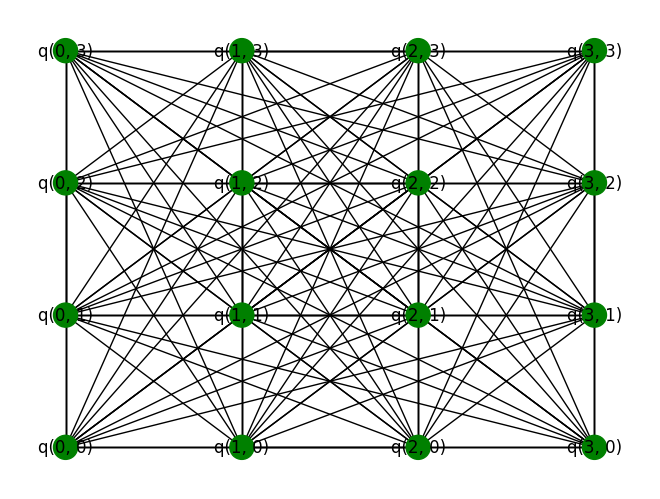

In [6]:
mv_layout = res.layout.MovementLayout(input_circuit=sub_circuit, num_t_factories=0)
mv_layout.draw()

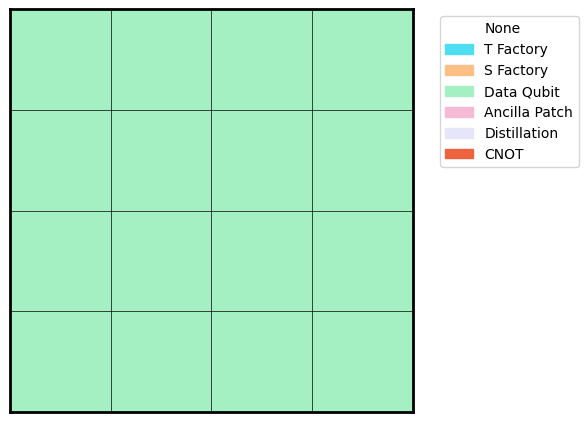

In [7]:

fig, ax, im = lfs.plot_layout(mv_layout, category_colors=category_colors, transpose=False)

In [8]:
fig, ax, im = lfs.plot_layout(ls_layout, category_colors=category_colors, transpose=False, show_legend=False)

NameError: name 'ls_layout' is not defined

In [ ]:
ls_layout = res.layout.FactorySandwich(input_circuit=sub_circuit, num_s_factories=0, num_t_factories=0)
ls_layout.draw()

## Send It!
This is what the compiler and estimator is for!

In [ ]:
for architecture, layout in [
    (res.architecture.DualSpeciesMovement(post_op_correction=False, idling=False), mv_layout),
    (res.architecture.MeasureZonesOnly(post_op_correction=False, idling=False), mv_layout),
    (res.architecture.DefaultMovement(post_op_correction=False, idling=False), mv_layout),
    (res.architecture.DefaultLattice(post_op_correction=False, idling=False), ls_layout),
]:
    print(architecture.__name__)
    primitive_circuit = cirq.synchronize_terminal_measurements(
        cirq.align_left(
            res.compile_ftqc.ft_compile(layout=layout, arc=architecture)
        )
    )[1:]
    display(primitive_circuit)
    estimator = res.estimate.ResourceEstimator(architecture)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        print([str(op.gate) for op in estimator.critical_path(primitive_circuit)])
    _time, _moments, _gates = estimator.parallel_circuit_time(primitive_circuit), estimator.parallel_circuit_cost(primitive_circuit), estimator.serial_circuit_cost(primitive_circuit)
    print(_time)
    pprint({GATE2STR[gate]: num for gate, num in _moments.items()})
    pprint({GATE2STR[gate]: num for gate, num in _gates.items()})